In [1]:
# KNN: EL ALGORITMO  DE K  VECINOS CERCANOS, ES UN CLASIFICADO DE APRENDIZAJE SUPERVISADO NO PARAMETRICO  QUE 
# UTILIZA LA PROXIMIDAD PARA HACER LAS CLASIFICACIONES  O PREDICCIONES SOBRE UNA AGRUPACION DE UN PUNTO DE DATOS 
# INDIVIDUALES 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as ss

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
# OTRAS LIBRERIAS NUEVAS 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [4]:
data = pd.read_csv('Social_Network_Ads.csv')

In [5]:
data.head(5) 

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
data.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [7]:
# para poder cambiar de valor a una columa o data 
#['Gender'] = data.Gender.astype(object)

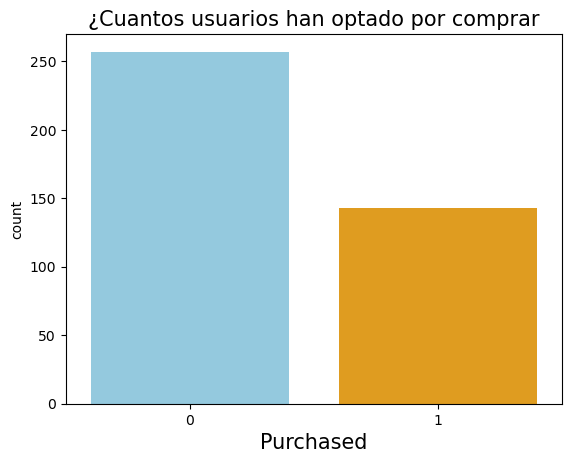

In [12]:
sns.countplot(
    data = data,
    x='Purchased',
    hue= 'Purchased',
    palette=['skyblue', 'orange'],
    legend=False
)

plt.xlabel('Purchased', fontsize=15)
plt.title('¿Cuantos usuarios han optado por comprar', fontsize=15)
plt.show()

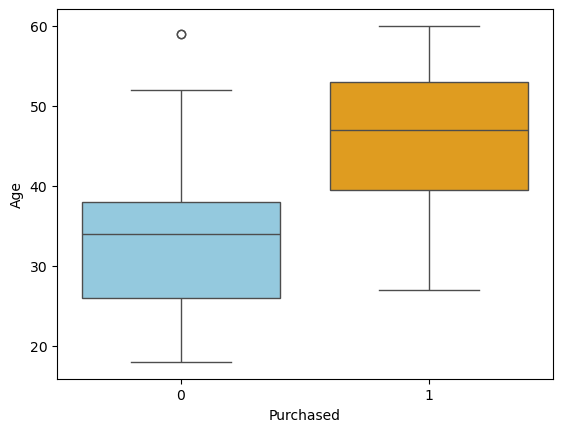

In [13]:
sns.boxplot(x='Purchased', y='Age', data=data,
           hue='Purchased',
           palette=['skyblue', 'orange'],
           legend=False)
plt.show()




In [14]:
# EN EL GRAFICO SE PRESENTA QUE LAS PERSONAS QUE COMPRARAN  TIENEN UNA EDAD  MEDIA Y MEDIANA (46 ) QUE LAS QUE NO 
# COMPRARON (PROMEDIO DE 34 AÑOS ) LO QUE SUGIERE QUE LA PROBABILIDAD DE COMPRAR AUMENTA POR  EDAD 

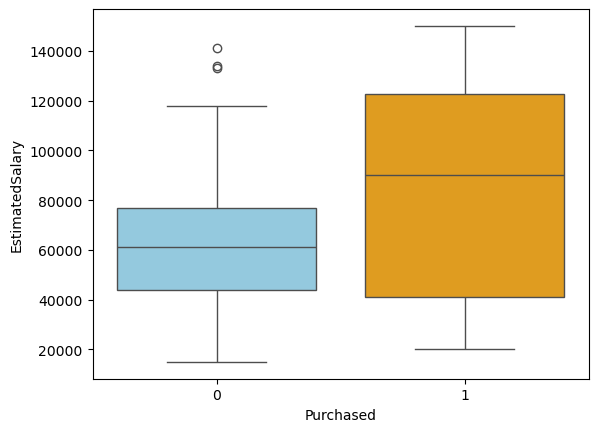

In [15]:
sns.boxplot(x='Purchased', y='EstimatedSalary', data=data,
           hue='Purchased',
           palette=['skyblue','orange'],
           legend=False)
plt.show()

Gender     Female  Male
Purchased              
0             127   130
1              77    66


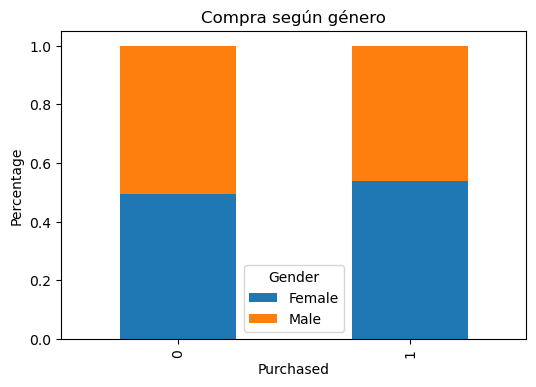

In [16]:
print(pd.crosstab(data["Purchased"], data["Gender"]))
Gender = pd.crosstab(data["Purchased"], data["Gender"])
Gender_percentage = Gender.div(
  Gender.sum(axis=1).astype(float),

  axis=0

)


Gender_percentage.plot(
  kind="bar",
  stacked=True,
  figsize=(6, 4)
)
plt.xlabel("Purchased")
plt.ylabel("Percentage")
plt.title("Compra según género")
plt.legend(title="Gender")
plt.show()

In [17]:
x = data.iloc[:,[2,3]].values # variables / datos predictoras (caracteristicas) # se toma variables: age y salario estimado 
y = data.iloc[:,-1] # variable objetivo (lo que queremos predecir) # se toma la variable purcharsed 

In [18]:
x[0:5]

array([[   19, 19000],
       [   35, 20000],
       [   26, 43000],
       [   27, 57000],
       [   19, 76000]])

In [19]:
y[0:5]

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [20]:
# vamos a dividir nuestros datos para el entrenamiento

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0) 

In [23]:
X_train[0:5]

array([[    58, 144000],
       [    59,  83000],
       [    24,  55000],
       [    26,  35000],
       [    58,  38000]])

In [24]:
X_test[0:5]

array([[   30, 87000],
       [   38, 50000],
       [   35, 75000],
       [   30, 79000],
       [   35, 50000]])

In [25]:
# en esta parte se convierte los datos originales a datos estadisticos: 
# media y desviacion estandar 
X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

In [26]:
X_train[0:5]

array([[ 1.92295008,  2.14601566],
       [ 2.02016082,  0.3787193 ],
       [-1.3822153 , -0.4324987 ],
       [-1.18779381, -1.01194013],
       [ 1.92295008, -0.92502392]])

In [27]:
X_test[0:5]

array([[-0.49618606,  0.56021375],
       [ 0.2389044 , -0.59133674],
       [-0.03675452,  0.18673792],
       [-0.49618606,  0.31122986],
       [-0.03675452, -0.59133674]])

In [30]:
# es para validacion cruzada 
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=5),x, y, cv=5)

# validacion cruzada: es un tecnica para comprobar si el modelo de machine learning realmente funciona de manera correct
# no es solo una division de los datos 

# cv= 5 : significa validacion cruzada de 5 particiones 
# cv_Scores: cv_scores.std()

In [31]:
print (cv_scores)

[0.8125 0.8625 0.725  0.7625 0.675 ]


In [32]:
print("CV_SCORES MEAN:{}".format(np.mean(cv_scores)))

CV_SCORES MEAN:0.7674999999999998


In [33]:
# tuning 
k_range = range(1,31)
k_scores = []

In [36]:
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x, y , cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

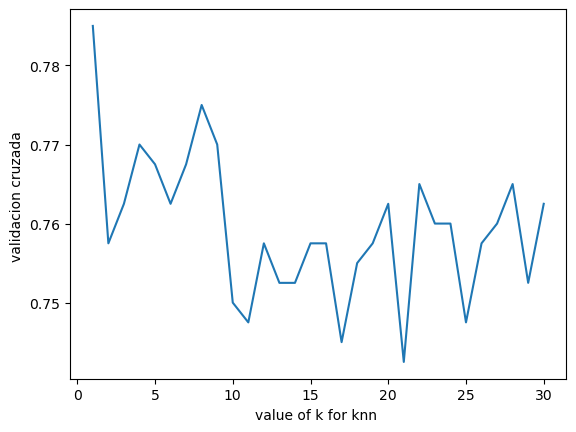

In [37]:
plt.plot(k_range, k_scores)
plt.xlabel('value of k for knn ')
plt.ylabel('validacion cruzada ')
plt.show()

In [38]:
tune = pd.concat([pd.DataFrame(k_range),pd.DataFrame(k_scores)],axis=1)
tune.columns = ['k_range', 'k_scores']
tune

,k_range,k_scores
0,1,0.7850
1,2,0.7575
2,3,0.7625
3,4,0.7700
4,5,0.7675
5,6,0.7625
6,7,0.7675
7,8,0.7750
8,9,0.7700
9,10,0.7500


In [39]:
# vamos a crear un modelo de knn  con K = 8 
# Para determina la clase nueva y ver los resultados con los k vecinos

In [40]:
classifier = KNeighborsClassifier(n_neighbors=8).fit(X_train, y_train)


In [41]:
y_pred = classifier.predict(X_test)

In [42]:
y_pred[0:5]

array([0, 0, 0, 0, 0])

In [43]:
y_test[0:5]

132    0
309    0
341    0
196    0
246    0
Name: Purchased, dtype: int64

In [44]:
confusion_matrix(y_test, y_pred)

array([[55,  3],
       [ 1, 21]])

Matriz de confusion sin normalidad
[[55  3]
 [ 1 21]]
Matriz de confusión normalizada
[[0.94827586 0.05172414]
 [0.04545455 0.95454545]]


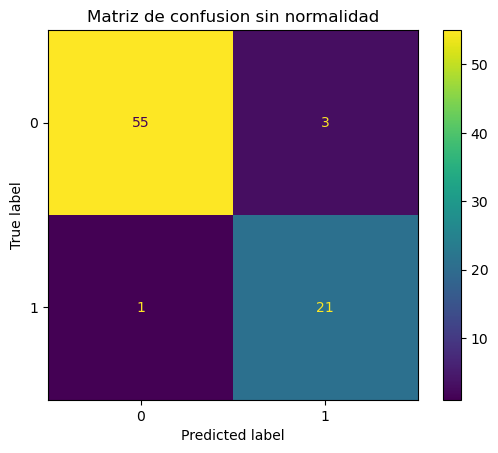

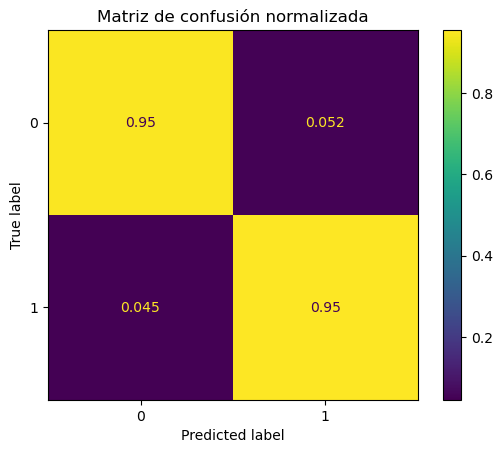

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
titles_options=[
    ("Matriz de confusion sin normalidad", None),
    ("Matriz de confusión normalizada","true")
]

for title, normalize in titles_options:
    disp =ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        normalize = normalize
    )
    disp.ax_.set_title(title)
    print(title)
    print(disp.confusion_matrix)
plt.show()

In [49]:
# aca hemos creado una linea de probabilidades que el modelo asigna a cada clase 
y_pred_prob = classifier.predict_proba(X_test)

In [50]:
y_pred_prob[0:5]

array([[0.5 , 0.5 ],
       [1.  , 0.  ],
       [0.75, 0.25],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [51]:
y_pred_prob[0:5,1]

array([0.5 , 0.  , 0.25, 0.  , 0.  ])

In [52]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_prob[:,1])


In [53]:
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.9788401253918495

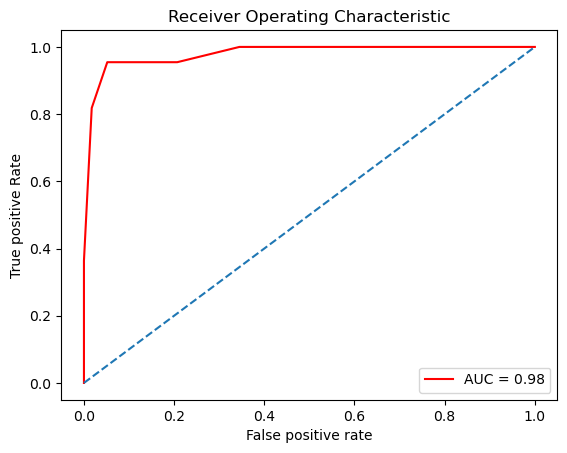

In [54]:
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate, true_positive_rate, color='red', label='AUC = %0.2F' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1], linestyle='--')
plt.axis('tight')
plt.ylabel('True positive Rate')
plt.xlabel('False positive rate')
plt.show()

In [55]:
# vamos a crear un tabla final con los datos de prueba, el valor real, la prediccion y la probabilidad
dataf= pd.concat([pd.DataFrame(X_test),pd.DataFrame(y_test),pd.DataFrame(y_pred),pd.DataFrame(y_pred_prob)],axis=1)

In [56]:
dataf.head(5)

,0,1,Purchased,0,0,1
0,-0.496186,0.560214,NaN,0.0,0.50,0.50
1,0.238904,-0.591337,0.0,0.0,1.00,0.00
2,-0.036755,0.186738,NaN,0.0,0.75,0.25
3,-0.496186,0.311230,NaN,0.0,1.00,0.00
4,-0.036755,-0.591337,0.0,0.0,1.00,0.00


In [57]:
dataf.columns=['Age','EstimatedSalary','Purchased','Purchased_Pred', 'Purchased_Pred_Prob_0','Purchased_Pred_Prob_1']

In [58]:
dataf.head(5)

,Age,EstimatedSalary,Purchased,Purchased_Pred,Purchased_Pred_Prob_0,Purchased_Pred_Prob_1
0,-0.496186,0.560214,NaN,0.0,0.50,0.50
1,0.238904,-0.591337,0.0,0.0,1.00,0.00
2,-0.036755,0.186738,NaN,0.0,0.75,0.25
3,-0.496186,0.311230,NaN,0.0,1.00,0.00
4,-0.036755,-0.591337,0.0,0.0,1.00,0.00


In [59]:
dataf.to_csv('dataf.csv', index= False)

In [ ]:
# Tarea: 
# Elaborar los modelos de: 
# 1. KNN 
# 2. KNN con SMOTE 
# 3. KNN con OVER 
# 4. KNN con under 

# Comparar modelos y presentar un cuadro resumen la sensibilidad, ROC, GINI: 